In [7]:
import numpy as np
from keras.models import load_model
import matplotlib.pyplot as plt
from PIL import Image

img = cv2.imread("1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (28, 28))
resized = resized / 255
resized = resized.reshape(1, 28, 28, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted digit: 2
Confidence: 23.42%


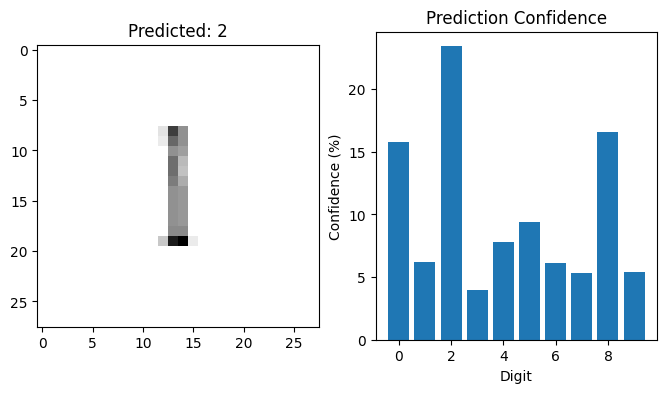

In [11]:
model = load_model("/Users/abdulaziz/Documents/Repository/projects/ArtificialIntelligence/MNIST/mnist_model.keras")
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Load and process image using PIL
img = Image.open("1.png").convert('L')  # Convert to grayscale
img = img.resize((28, 28))  # Resize to MNIST format
img_array = np.array(img)
img_array = img_array.astype('float32') / 255
img_array = img_array.reshape(1, 28, 28, 1)

# Get prediction and probabilities
pred = model.predict(img_array)
digit = np.argmax(pred)
probability = np.max(pred) * 100  # Convert to percentage

print('Predicted digit:', digit)
print('Confidence: {:.2f}%'.format(probability))

# Plot the image and metrics
plt.figure(figsize=(8, 4))

# Plot the digit
plt.subplot(1, 2, 1)
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title(f'Predicted: {digit}')

# Plot the probabilities
plt.subplot(1, 2, 2)
plt.bar(range(10), pred[0] * 100)
plt.title('Prediction Confidence')
plt.xlabel('Digit')
plt.ylabel('Confidence (%)')
plt.show()